## Значения переменых

| Переменная | Описание | Тип |
|------------|---------|-----|
| **tenure**  | Месяцев с компанией (0-72) | int |
| **Contract**  | Месячный/годовой/двухлетний контракт | категория |
| **PaymentMethod**  | Электронный чек vs автоматический | категория |
| **InternetService** | DSL vs Fiber optic| категория |
| **TechSupport** | Техподдержка (Yes/No) | категория |
| **OnlineSecurity** | Безопасность подписка | категория |
| MonthlyCharges | Месячный счет $ | float |
| TotalCharges | Всего платежей $| float |
| gender | Пол | категория |
| SeniorCitizen | Пожилой (0/1) | int - по факту категориальная |
| Partner | Есть партнер | категория |
| Dependents | Есть иждивенцы | категория |
| PhoneService | Телефон | категория |
| MultipleLines | Несколько линий | категория |
| OnlineBackup | Облачное резервное копирование | категория |
| DeviceProtection | Страховка устройств | категория |
| StreamingTV | ТВ онлайн | категория |
| StreamingMovies | Кино онлайн | категория |
| PaperlessBilling | Электронные счета | категория |
| **Churn** | Целевая переменная (Yes/No) | категория |

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline


In [93]:
df = pd.read_csv('../../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Базовая информация о данных


In [94]:
# Размерность и типы данных
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [95]:
# Описательные статистики
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [96]:
df['SeniorCitizen'].unique()

array([0, 1])

SeniorCitizen - оказалась категориальной, преобразуем тип

In [97]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')


In [98]:
# Проверка пропусков
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 2. Анализ целевой переменной (Churn)

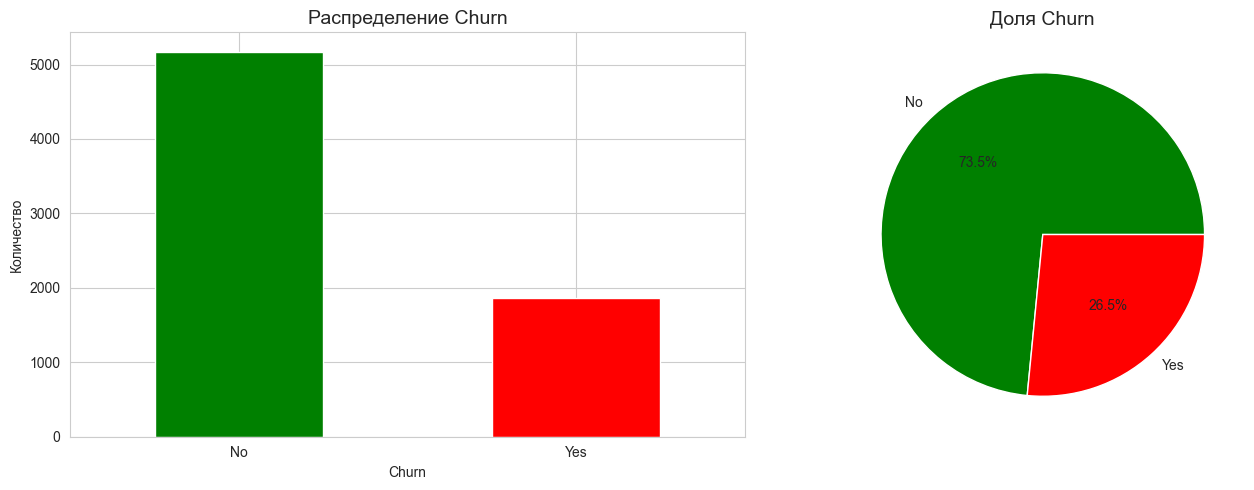

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [99]:
# Распределение Churn - целевая фича
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df['Churn'].value_counts().plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Распределение Churn', fontsize=14)
ax1.set_ylabel('Количество')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                                 colors=['green', 'red'])
ax2.set_ylabel('')
ax2.set_title('Доля Churn', fontsize=14)

plt.tight_layout()
plt.show()

df['Churn'].value_counts()


## 3. Числовые переменные

Анализируем: tenure, MonthlyCharges, TotalCharges

In [100]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
numerical_cols

['tenure', 'MonthlyCharges']

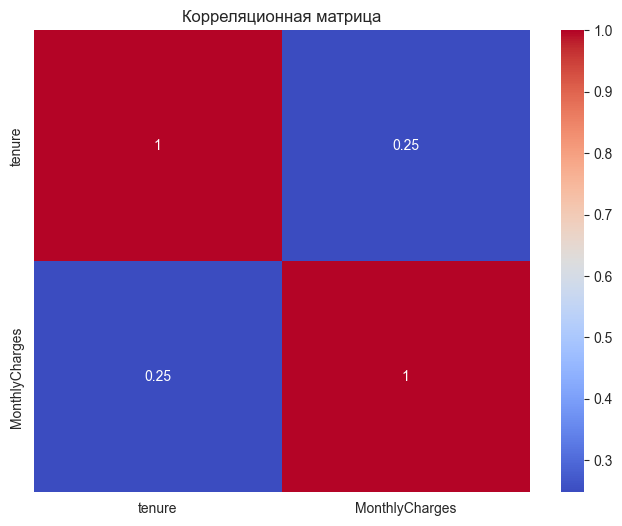

In [101]:
# Корреляционная матрица
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()


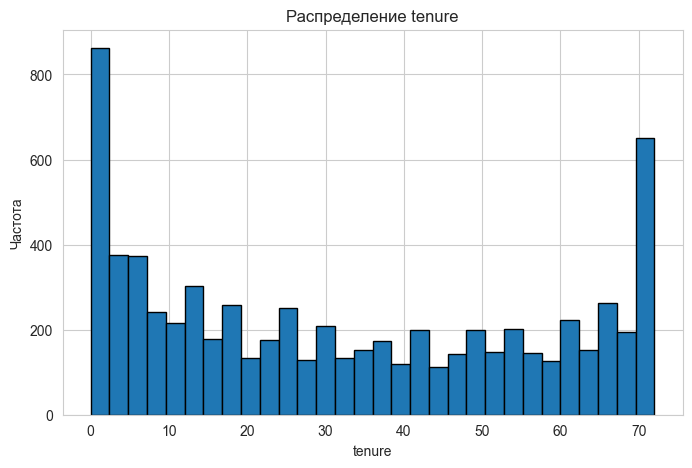

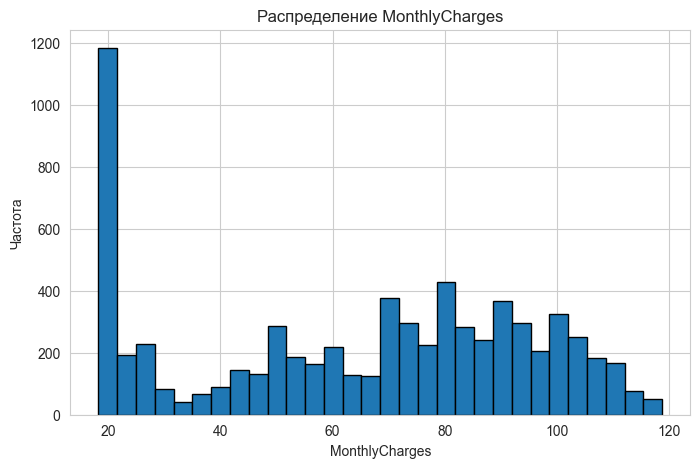

In [102]:
# Распределение числовых переменных
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()


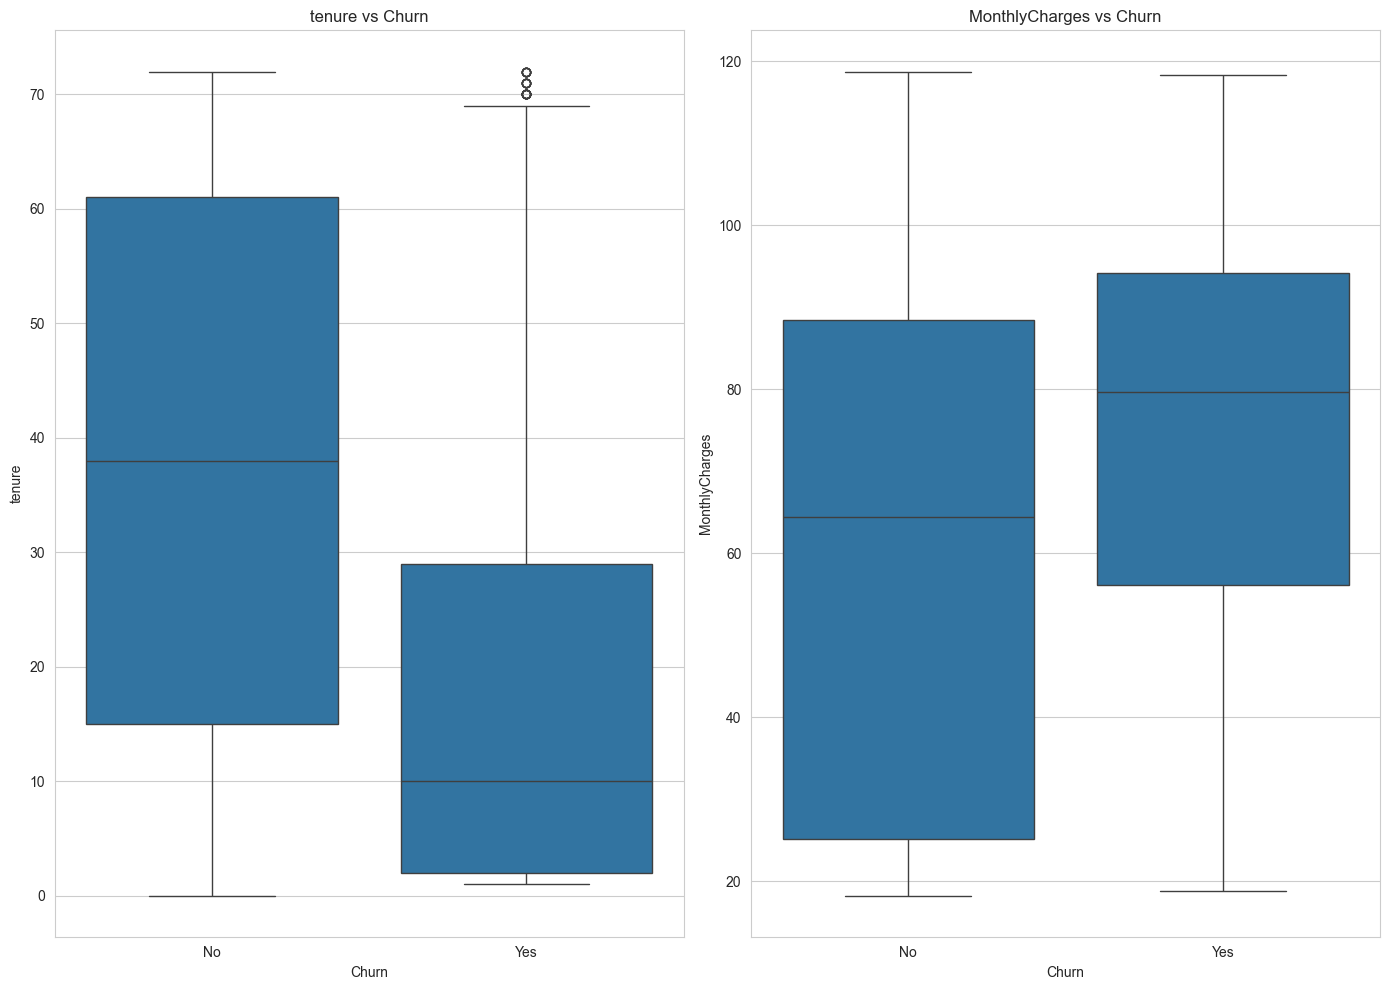

In [103]:
# Связь числовых переменных с Churn через boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} vs Churn')
    

plt.tight_layout()
plt.show()


In [104]:
df['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [105]:
# Сравнение средних значений
df.groupby('Churn')[numerical_cols].mean()


,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [106]:
# Выбросы в числовых переменных
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(df)*100:.1f}%)")


tenure: 0 выбросов (0.0%)
MonthlyCharges: 0 выбросов (0.0%)


Выбросов не оказалось

## 5. Категориальные переменные


<Figure size 1000x600 with 0 Axes>

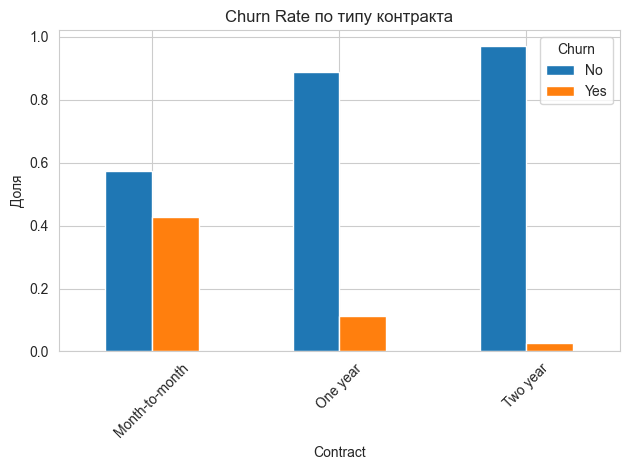

In [107]:
plt.figure(figsize=(10, 6))
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar')
plt.title('Churn Rate по типу контракта')
plt.ylabel('Доля')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [108]:
# Категориальные столбцы
cat_cols = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').nunique() < 10
].tolist()
 
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

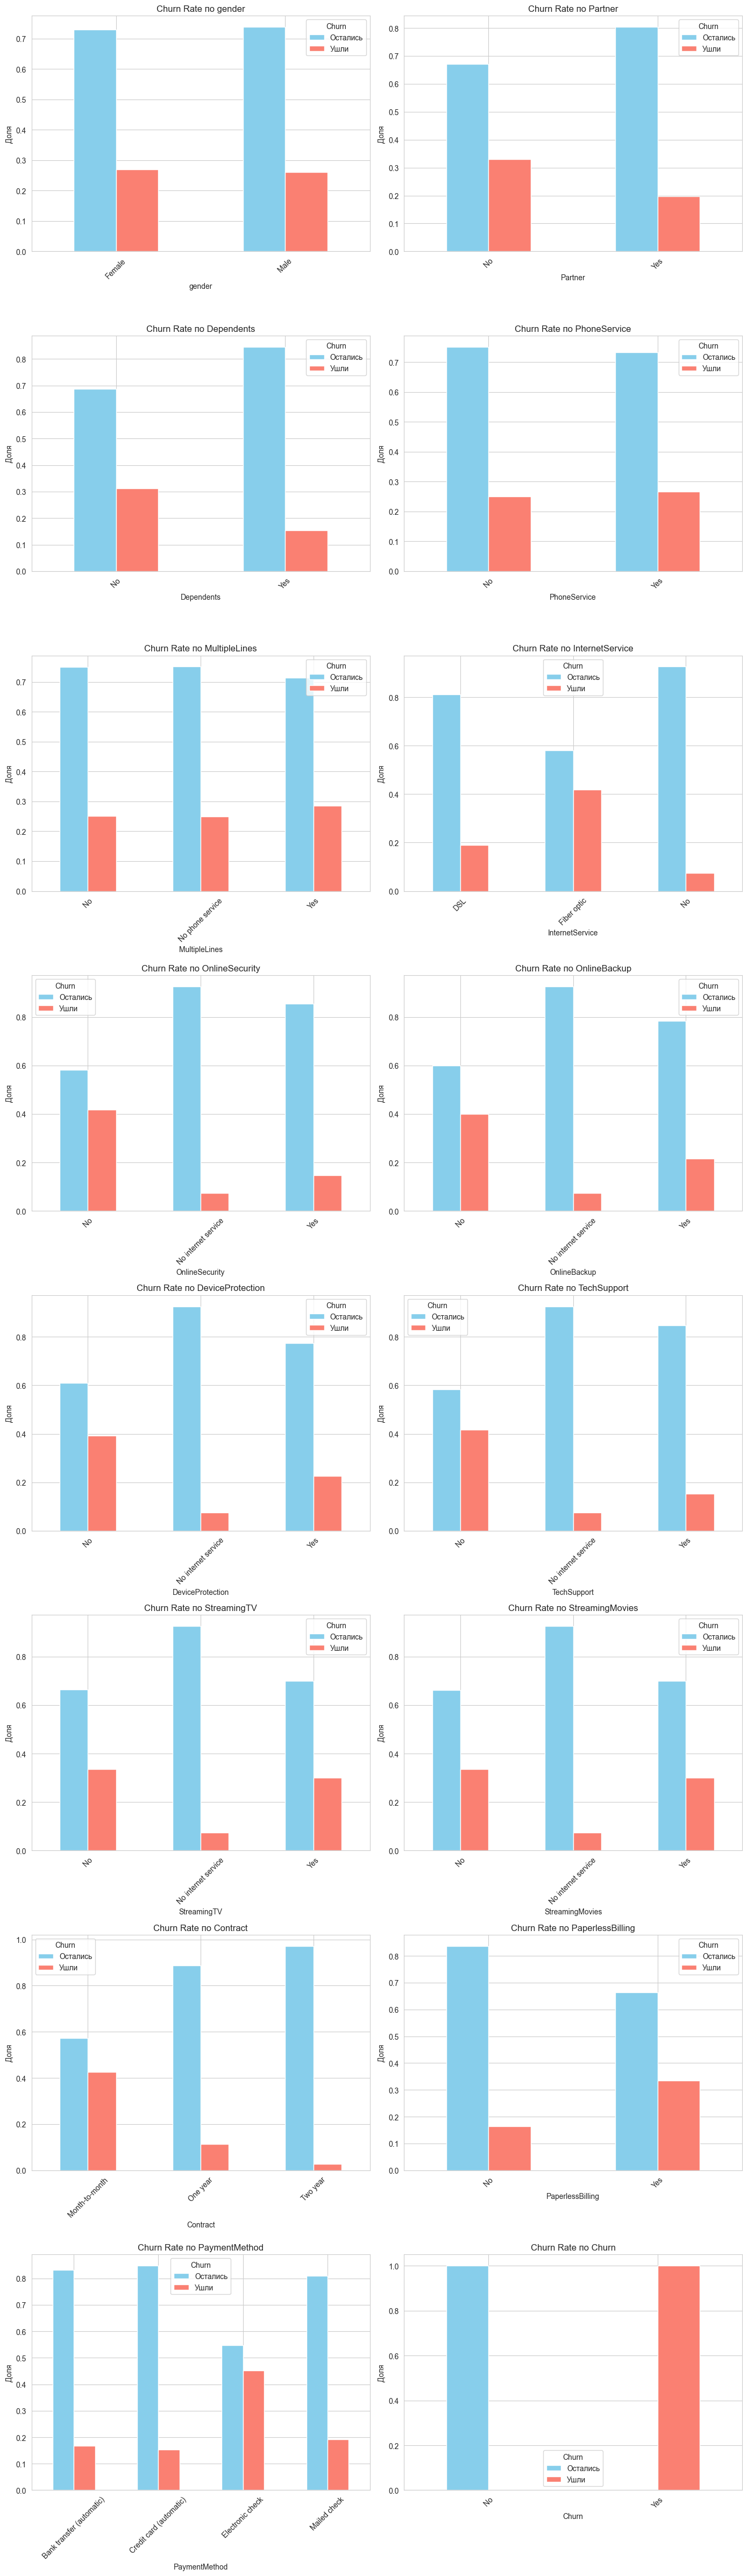

In [109]:
n_cols = len(cat_cols)
cols_per_row = 2
rows = int(n_cols / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 6 * rows))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    churn_rate = pd.crosstab(df[col], df['Churn'], normalize='index')
    churn_rate.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'])
    ax.set_title(f'Churn Rate по {col}')
    ax.set_ylabel('Доля')
    ax.set_xlabel(col)
    ax.legend(title='Churn', labels=['Остались', 'Ушли'])
    ax.tick_params(axis='x', rotation=45)

for idx in range(n_cols, len(axes)):
    ax = axes[idx]
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Выводы по EDA

## Данные

- **7043 записи**, 21 признак, пропуски отсутствуют
- **Дисбаланс классов**: 73.5% лояльных vs 26.5% ушедших
- Требуется SMOTE/class_weight при моделировании

## Возможные факторы оттока (предварительные гипотезы)

### Tenure (срок обслуживания)
**Главный предиктор**: ушедшие клиенты — 18 мес, лояльные — 38 мес. Первые 18 месяцев — критический период.

### Contract (тип контракта)
**Month-to-month**: 40-45% churn (максимум). Долгосрочные контракты снижают отток в 3-4 раза.

### MonthlyCharges (тариф)
Ушедшие платят **$74**, лояльные — **$61**. Высокая цена = высокий риск оттока.

### SeniorCitizen
Пенсионеры уходят в **2 раза чаще** (25% vs 13%).

### Дополнительные услуги
Отсутствие OnlineSecurity, TechSupport, OnlineBackup значительно повышает churn.

### InternetService
**Fiber optic** показывает больший отток, чем DSL (при более высокой цене).

### Gender
**Не влияет** на отток.
